# Meilenstein 2: Data Exploration - Missing Values (Deep Dive)

## 1. Kontext
Im vorhergehenden Notebook [05-01_Data_Exploration.ipynb](05-01_Data_Exploration.ipynb) wurde eine erste, schnelle Missing-Value-Quantifizierung auf Basis von `pd.isna()` durchgeführt. Das deckt **nur** Werte ab, die Pandas/NumPy bereits als `NaN` interpretiert.

Reale Datensätze - vor allem solche aus Web-Scraping (vgl. unsere Skripte unter `src/scraping/code/`) - enthalten zusätzlich **versteckte Missings** in Form von String-Platzhaltern (`"n/a"`, `"NULL"`, `"-"`, `"ka"`, ...) oder numerischen Sentinels (`-1`, `-999`, ...). Diese werden von `pd.isna()` **nicht** erkannt und verzerren Statistik und Modellierung.

## 2. Zielsetzung dieses Notebooks
- Wissenschaftlich begründeten **Platzhalter-Katalog** anwenden
- Den gesamten Datensatz `09_cleaned_master_data.pkl` **systematisch** auf diese Platzhalter prüfen.
- Ergebnisse pro Spalte **quantifizieren** (`n_native_nan`, `n_placeholder_hits`, `effective_missing_pct`) und **visualisieren** (Stacked Bar, Co-Missingness Heatmap).
- Konkrete **Empfehlungen** für den späteren Imputations-/Encoding-Schritt  ableiten.

## 3. Methodik
Quellen (vollständige Liste in der Begleit-Doku):
- van Buuren (2018): Klassifikation MCAR / MAR / MNAR.
- de Jonge & van der Loo (2013): Special values & missing data im Data-Cleaning-Prozess.
- Wickham (2014, *Tidy Data*): Behandlung versteckter Missings beim Tidying.
- Rahm & Do (2000): Dummy- und cryptic values als typische Single-Source-Probleme.
- Pandas-Doku zu `read_csv(na_values=...)` als pragmatische Default-Liste.

> Hinweis: Dieses Notebook ist **read-only**. Es schreibt kein neues Pickle.

In [ ]:
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_PATH = "../../data/processed/10_cleaned_master_data.pkl"
df = pd.read_pickle(DATA_PATH)

print(f"Shape: {df.shape[0]:,} Zeilen x {df.shape[1]} Spalten")
print("\nDatentypen:")
print(df.dtypes.value_counts())

Shape: 225,692 Zeilen x 36 Spalten

Datentypen:
float64           19
object            13
int64              2
datetime64[us]     1
datetime64[ns]     1
Name: count, dtype: int64


## 4. Platzhalter-Katalog

| Gruppe | Quelle | Behandlung |
|---|---|---|
| `PANDAS_DEFAULT_NA` | Pandas `read_csv` Default | erkennen, zu `NaN` konvertierbar |
| `LITERATURE_PLACEHOLDERS` | de Jonge & van der Loo (2013); Rahm & Do (2000); Wickham (2014) | erkennen, zu `NaN` konvertierbar |
| `GERMAN_PLACEHOLDERS` | typische deutsche Datensätze | erkennen, zu `NaN` konvertierbar |
| `DOMAIN_PLACEHOLDERS` | unsere Scraper (`01_stage_results.py`) | spaltenspezifisch, vorsichtig |
| `NUMERIC_SENTINELS` | klassische numerische Codes für fehlende Werte | nur **Reporting**, keine Auto-Konvertierung |

In [2]:
PANDAS_DEFAULT_NA = {
    "", "#N/A", "#N/A N/A", "#NA", "-1.#IND", "-1.#QNAN",
    "-NaN", "-nan", "1.#IND", "1.#QNAN", "<NA>", "N/A",
    "NA", "NULL", "NaN", "None", "n/a", "nan", "null",
}

LITERATURE_PLACEHOLDERS = {
    "?", "-", "--", "---", ".",
    "missing", "Missing", "unknown", "Unknown",
    "NIL", "nil", "NONE", "none",
    "#REF!", "#DIV/0!", "#VALUE!", "#NUM!",
}

GERMAN_PLACEHOLDERS = {
    "ka", "k.A.", "k. A.", "keine Angabe",
    "unbekannt", "n.v.", "nicht verfügbar",
}

DOMAIN_PLACEHOLDERS_PER_COLUMN = {
    "race_ranking": {"n/a"},
    "rank": {"DNF", "DNS", "DSQ", "OTL", "HD"},
}

ALL_STRING_PLACEHOLDERS = (
    PANDAS_DEFAULT_NA | LITERATURE_PLACEHOLDERS | GERMAN_PLACEHOLDERS
)

NON_MISSING_DOMAIN_MARKERS = {
    "time_gap": {",,0:00"},
}

NUMERIC_SENTINELS = {-1, -999, -9999, 9999, 99999}

print(f"Pandas-Default-Strings    : {len(PANDAS_DEFAULT_NA)}")
print(f"Literatur-Strings         : {len(LITERATURE_PLACEHOLDERS)}")
print(f"Deutsche Strings          : {len(GERMAN_PLACEHOLDERS)}")
print(f"Vereinigt (ohne Domain)   : {len(ALL_STRING_PLACEHOLDERS)}")
print(f"Domain pro Spalte         : {DOMAIN_PLACEHOLDERS_PER_COLUMN}")
print(f"Sieger-/Marker (NICHT NA) : {NON_MISSING_DOMAIN_MARKERS}")
print(f"Numerische Sentinels      : {sorted(NUMERIC_SENTINELS)}")

Pandas-Default-Strings    : 19
Literatur-Strings         : 17
Deutsche Strings          : 7
Vereinigt (ohne Domain)   : 43
Domain pro Spalte         : {'race_ranking': {'n/a'}, 'rank': {'DNS', 'DSQ', 'HD', 'OTL', 'DNF'}}
Sieger-/Marker (NICHT NA) : {'time_gap': {',,0:00'}}
Numerische Sentinels      : [-9999, -999, -1, 9999, 99999]


## 5. Detection-Helper

Zwei Helfer-Funktionen, klar getrennt nach Spaltentyp:

- `detect_string_placeholders(series, candidates)` arbeitet **case-insensitive** und trimmt vorher Whitespace. Reine Whitespace-Strings (`"  "`) werden ebenfalls als Platzhalter gezählt.
- `detect_numeric_sentinels(series, candidates)` zählt nur exakte Treffer und ignoriert `NaN`. Reines Reporting - **kein** Auto-Replace.

Beide Funktionen geben ein Dictionary `{platzhalter: count}` zurück (nur Platzhalter mit `count > 0`).

In [3]:
def detect_string_placeholders(series: pd.Series, candidates: set) -> dict:
    """Zählt case-insensitive Treffer der Platzhalter in einer Serie.

    Whitespace wird vorher entfernt; ein leerer String zählt als Platzhalter,
    wenn `""` im Kandidaten-Set ist. Native NaN werden nicht mitgezählt.
    """
    if series.dtype != object:
        return {}
    norm = series.dropna().astype(str).str.strip()
    cand_lower = {c.lower(): c for c in candidates}
    hits = norm.str.lower().value_counts()
    return {
        cand_lower[val]: int(count)
        for val, count in hits.items()
        if val in cand_lower
    }


def detect_numeric_sentinels(series: pd.Series, candidates: set) -> dict:
    """Zählt exakte Treffer numerischer Sentinel-Werte (z. B. -1, -999)."""
    if not pd.api.types.is_numeric_dtype(series):
        return {}
    clean = series.dropna()
    return {
        sentinel: int((clean == sentinel).sum())
        for sentinel in candidates
        if (clean == sentinel).any()
    }


_demo_col = "race_ranking" if "race_ranking" in df.columns else df.columns[0]
print(f"Demo - String-Platzhalter in `{_demo_col}`:")
print(detect_string_placeholders(df[_demo_col], ALL_STRING_PLACEHOLDERS))

Demo - String-Platzhalter in `race_ranking`:
{'n/a': 164674}


## 6. Aggregierte Missing-Tabelle

Pro Spalte wird zusammengefasst:

| Spalte | Bedeutung |
|---|---|
| `dtype` | aktueller Datentyp |
| `n_native_nan` | von `pd.isna()` bereits erkannte fehlende Werte |
| `n_placeholder_hits` | Summe versteckter String-Platzhalter |
| `n_effective_missing` | `n_native_nan + n_placeholder_hits` |
| `effective_missing_pct` | `n_effective_missing / len(df) * 100` |
| `placeholders_found` | bis zu 3 häufigste Platzhalter inkl. Count |
| `numeric_sentinels_found` | Treffer der numerischen Sentinels (Reporting) |

Die Tabelle wird nach `effective_missing_pct` absteigend sortiert.

In [4]:
def _format_top(d: dict, top: int = 3) -> str:
    if not d:
        return ""
    items = sorted(d.items(), key=lambda kv: kv[1], reverse=True)[:top]
    return ", ".join(f"{k!r} ({v})" for k, v in items)


rows = []
n_total = len(df)

for col in df.columns:
    series = df[col]
    n_native_nan = int(series.isna().sum())

    domain_extra = DOMAIN_PLACEHOLDERS_PER_COLUMN.get(col, set())
    string_candidates = ALL_STRING_PLACEHOLDERS | domain_extra
    string_hits = detect_string_placeholders(series, string_candidates)

    markers_to_drop = NON_MISSING_DOMAIN_MARKERS.get(col, set())
    for marker in markers_to_drop:
        string_hits.pop(marker, None)

    numeric_hits = detect_numeric_sentinels(series, NUMERIC_SENTINELS)

    n_placeholder = sum(string_hits.values())
    n_effective = n_native_nan + n_placeholder
    rows.append(
        {
            "column": col,
            "dtype": str(series.dtype),
            "n_native_nan": n_native_nan,
            "n_placeholder_hits": n_placeholder,
            "n_effective_missing": n_effective,
            "effective_missing_pct": round(100 * n_effective / n_total, 2),
            "placeholders_found": _format_top(string_hits),
            "numeric_sentinels_found": _format_top(numeric_hits),
        }
    )

missing_overview = (
    pd.DataFrame(rows)
    .set_index("column")
    .sort_values("effective_missing_pct", ascending=False)
)

n_affected = int(
    (
        (missing_overview["n_effective_missing"] > 0)
        | (missing_overview["numeric_sentinels_found"] != "")
    ).sum()
)
print(
    f"Spalten mit Missings ODER numerischen Sentinels: {n_affected} "
    f"von {df.shape[1]}"
)
missing_overview

Spalten mit Missings ODER numerischen Sentinels: 17 von 36


,dtype,n_native_nan,n_placeholder_hits,n_effective_missing,effective_missing_pct,placeholders_found,numeric_sentinels_found
column,,,,,,,
race_ranking,object,0,164674,164674,72.96,'n/a' (164674),
team_class,object,6366,0,6366,2.82,,
current_team,object,6366,0,6366,2.82,,
won_how,object,0,6081,6081,2.69,'-' (6081),
profile_score,float64,5312,0,5312,2.35,,
vertical_meters,float64,5312,0,5312,2.35,,
time_gap,object,0,5186,5186,2.30,'n/a' (5186),
rider_rank_season,float64,4762,0,4762,2.11,,
rider_points_season,float64,4762,0,4762,2.11,,


## 7. Visualisierung

### 7.1 Stacked Bar: native NaN vs. versteckte Platzhalter
Zeigt nur Spalten, die mindestens einen native NaN **oder** einen Platzhalter aufweisen. So sieht man auf einen Blick, ob das Hauptproblem reine `NaN` oder versteckte Platzhalter sind.

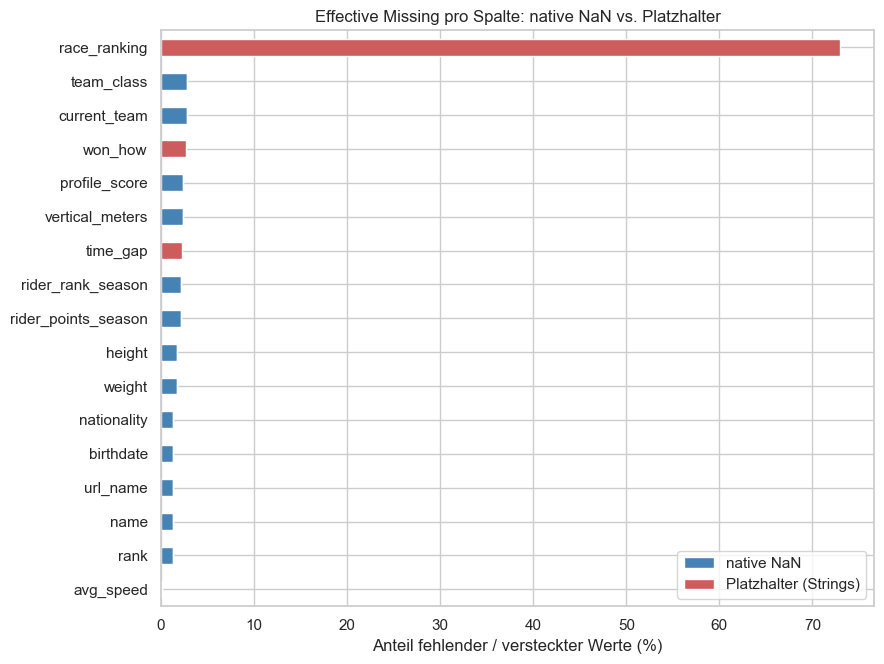

In [5]:
plot_df = missing_overview.query("n_effective_missing > 0").copy()
plot_df = plot_df[["n_native_nan", "n_placeholder_hits"]]

if plot_df.empty:
    print("Keine Spalten mit nativen NaN oder Platzhaltern.")
else:
    plot_df_pct = 100 * plot_df / n_total
    fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(plot_df_pct))))
    plot_df_pct.plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=["steelblue", "indianred"],
    )
    ax.set_xlabel("Anteil fehlender / versteckter Werte (%)")
    ax.set_ylabel("")
    ax.set_title("Effective Missing pro Spalte: native NaN vs. Platzhalter")
    ax.legend(["native NaN", "Platzhalter (Strings)"], loc="lower right")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

### 7.2 Co-Missingness-Heatmap

Zeigt, wo (zeilenweise) Missings im Datensatz auftreten. Dichte Streifen deuten auf **strukturelle** Missings hin (z. B. Rookies, fehlende Etappen-Metadaten), während zerstreute Muster eher MAR/MCAR sind. Für die Lesbarkeit wird auf eine Stichprobe von 5.000 Zeilen reduziert.

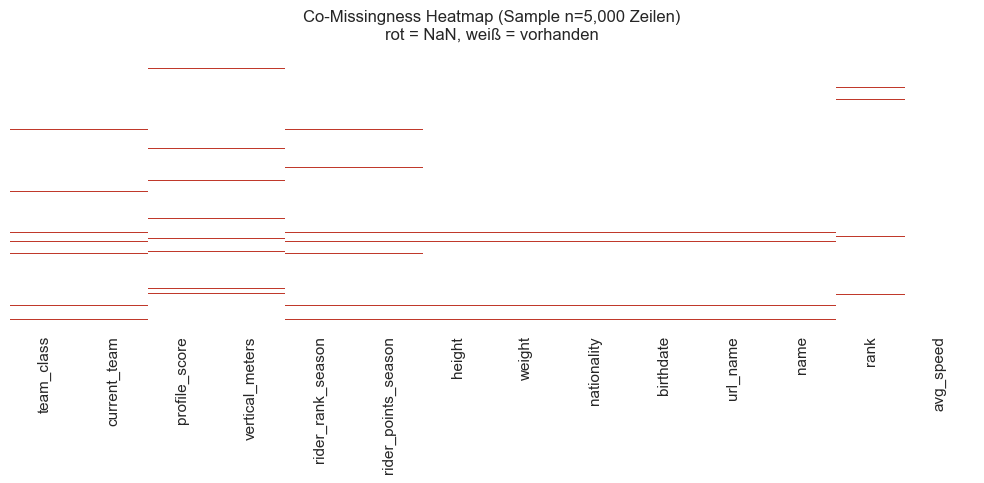

In [6]:
cols_with_missings = missing_overview.query("n_native_nan > 0").index.tolist()

if not cols_with_missings:
    print("Keine Spalten mit native NaN - Heatmap entfällt.")
else:
    sample_n = min(5_000, len(df))
    sample = df[cols_with_missings].sample(
        n=sample_n, random_state=42
    ).sort_index()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        sample.isna(),
        cbar=False,
        yticklabels=False,
        cmap=["#ffffff", "#c0392b"],
        ax=ax,
    )
    ax.set_title(
        f"Co-Missingness Heatmap (Sample n={sample_n:,} Zeilen)\n"
        "rot = NaN, weiß = vorhanden"
    )
    ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

## 8. Domäne im Fokus

Vier Spalten verdienen eine genauere Betrachtung, weil Platzhalter dort entweder **dominieren** oder **semantisch nicht missing** sind.

| Spalte | Beobachtung | Konsequenz |
|---|---|---|
| `race_ranking` | `"n/a"` dominiert (~ 73 %) | echte Missings - in 05-03 zu `NaN` oder Kategorie `"unbekannt"` |
| `time_gap` | `",,0:00"` = **Sieger** (nicht missing); `"n/a"` = echtes Missing | bei String-Parsing in Sekunden ist `",,0:00"` -> `0`, `"n/a"` -> `NaN` |
| `rank` | `NaN` markiert DNF/DNS/DSQ - MNAR | **nicht** imputieren, separat als Flag modellieren |
| Spezialisierungs-Scores | `0` ist legitim - **kein** Sentinel | keine Konvertierung, aber Reporting der Null-Häufigkeit |

In [7]:
if "race_ranking" in df.columns:
    print("=== race_ranking ===")
    rr = df["race_ranking"].astype(str).str.strip()
    n_na_string = int((rr.str.lower() == "n/a").sum())
    print(f"Einträge gesamt              : {len(rr):,}")
    print(f"Native NaN                  : {int(df['race_ranking'].isna().sum()):,}")
    print(f"String 'n/a' (case-insens.) : {n_na_string:,} "
          f"({n_na_string / len(rr) * 100:.2f} %)")
    print("Top-5 unique:")
    print(rr.value_counts().head())
else:
    print("Spalte `race_ranking` nicht vorhanden.")

=== race_ranking ===
Einträge gesamt              : 225,692
Native NaN                  : 0
String 'n/a' (case-insens.) : 164,674 (72.96 %)
Top-5 unique:
race_ranking
n/a    164674
1       20747
11       7027
8        6833
12       6786
Name: count, dtype: int64


In [8]:
if "time_gap" in df.columns:
    print("=== time_gap ===")
    tg = df["time_gap"].astype(str).str.strip()
    winner_mask = tg == ",,0:00"
    na_mask = tg.str.lower() == "n/a"
    print(f"Einträge gesamt        : {len(tg):,}")
    print(f"Sieger-Marker ',,0:00' : {int(winner_mask.sum()):,} "
          f"({winner_mask.mean() * 100:.2f} %) - NICHT missing")
    print(f"String 'n/a'           : {int(na_mask.sum()):,} "
          f"({na_mask.mean() * 100:.2f} %) - echtes Missing")
    print("Top-5 unique (gekürzt):")
    print(tg.value_counts().head())
else:
    print("Spalte `time_gap` nicht vorhanden.")

=== time_gap ===
Einträge gesamt        : 225,692
Sieger-Marker ',,0:00' : 40,004 (17.73 %) - NICHT missing
String 'n/a'           : 5,186 (2.30 %) - echtes Missing
Top-5 unique (gekürzt):
time_gap
,,0:00    40004
n/a        5186
,,0:05     1199
,,0:04     1014
,,0:03      774
Name: count, dtype: int64


In [9]:
if "rank" in df.columns:
    print("=== rank (Zielvariable, MNAR) ===")
    rank_series = df["rank"]
    n_nan = int(rank_series.isna().sum())
    print(f"Einträge gesamt : {len(rank_series):,}")
    print(f"NaN (DNF/DNS)  : {n_nan:,} ({n_nan / len(rank_series) * 100:.2f} %)")
    if rank_series.dtype == object:
        text_values = (
            rank_series.dropna()
            .astype(str)
            .str.upper()
            .value_counts()
        )
        text_codes = text_values[
            text_values.index.isin({"DNF", "DNS", "DSQ", "OTL", "HD"})
        ]
        if not text_codes.empty:
            print("Domain-Codes als Text:")
            print(text_codes)
else:
    print("Spalte `rank` nicht vorhanden.")

=== rank (Zielvariable, MNAR) ===
Einträge gesamt : 225,692
NaN (DNF/DNS)  : 2,852 (1.26 %)


In [10]:
spec_cols = [
    "one_day_races", "gc", "time_trial",
    "sprint", "climber", "hills",
]
spec_cols = [c for c in spec_cols if c in df.columns]

if spec_cols:
    spec_stats = pd.DataFrame(
        {
            "n_native_nan": df[spec_cols].isna().sum(),
            "n_zeros": (df[spec_cols] == 0).sum(),
            "zero_pct": (df[spec_cols] == 0).mean().mul(100).round(2),
        }
    )
    print("=== Spezialisierungs-Scores (0 = legitim, KEIN Sentinel) ===")
    print(spec_stats)
else:
    print("Keine Spezialisierungs-Score-Spalten gefunden.")

=== Spezialisierungs-Scores (0 = legitim, KEIN Sentinel) ===
               n_native_nan  n_zeros  zero_pct
one_day_races             0     3244      1.44
gc                        0     2892      1.28
time_trial                0     8786      3.89
sprint                    0    13655      6.05
climber                   0     5288      2.34
hills                     0     7221      3.20


## 9. Empfehlungen für Notebook 05-03 (Imputation/Encoding)

Aus den obigen Beobachtungen leiten wir folgende konkrete Aktionen ab. Diese werden **nicht** hier ausgeführt - dieses Notebook bleibt read-only.

| Spalte(n) | Beobachteter Platzhalter | Empfehlung in 05-03 |
|---|---|---|
| `race_ranking` | `"n/a"` (~73 %) | zu echtem `NaN` konvertieren **oder** als Kategorie `"unbekannt"` belassen (Domain-Entscheidung; die hohe Quote macht beide Optionen vertretbar) |
| `time_gap` | `",,0:00"` (Sieger) **vs.** `"n/a"` (echtes Missing) | beim Parsing in Sekunden: `",,0:00"` -> `0.0`, `"n/a"` -> `NaN` |
| `rank` | `NaN` = DNF/DNS/DSQ (MNAR) | **nicht** imputieren; zusätzliche binäre Spalte `did_not_finish` einführen |
| `rider_points_season`, `rider_rank_season` | `NaN` für Rookies | mit `0` imputieren **und** Flag `is_rookie` setzen |
| `weight`, `height` | `NaN` durch unvollständige PCS-Profile | Median-Imputation, gruppiert nach `nationality` (bzw. Jahr) |
| Wetter-Spalten | vereinzelte `NaN` durch fehlende Geo-Treffer | Median pro Renntag bzw. Etappen-Cluster |
| `current_team`, `team_class` | `NaN` durch Vertragslücken | Forward-Fill auf Fahrerebene oder Kategorie `"unknown"` |
| Spezialisierungs-Scores | `0` = legitim | **keine** Konvertierung, ggf. zusätzliche Spalte `is_unscored` falls Verteilung sehr schief |

> Allgemein: Bevor Platzhalter ungesehen zu `NaN` konvertiert werden, sollte immer geprüft werden, ob es einen semantischen Unterschied gibt (`time_gap` ist das Paradebeispiel). Die wissenschaftliche Grundlage findet sich in [`Dokumentation/05-02_missing_values.md`](../../Dokumentation/05-02_missing_values.md).